In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Cardiovascular_Disease_Dataset.csv')
df.head(5)
df.shape

(1000, 14)

In [3]:
X=df.drop(['target','patientid'], axis='columns')
y=df['target']
X.shape
y.shape
X

,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels
0,53,1,2,171,0,0,1,147,0,5.3,3,3
1,40,1,0,94,229,0,1,115,0,3.7,1,1
2,49,1,2,133,142,0,0,202,1,5.0,1,0
3,43,1,0,138,295,1,1,153,0,3.2,2,2
4,31,1,1,199,0,0,2,136,0,5.3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...
995,48,1,2,139,349,0,2,183,1,5.6,2,2
996,47,1,3,143,258,1,1,98,1,5.7,1,0
997,69,1,0,156,434,1,0,196,0,1.4,3,1
998,45,1,1,186,417,0,1,117,1,5.9,3,2


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

In [33]:
lr=LogisticRegression(solver='liblinear', max_iter=100, class_weight='balanced')
rfc=RandomForestClassifier(n_estimators=200)
xgb_model=xgb.XGBClassifier(n_estimators=100, learning_rate =0.01)
svc=SVC(kernel='poly',)
from sklearn.metrics import recall_score, make_scorer
models={'Logistic Regression':lr, 'Random Forest':rfc, 'XGBoost':xgb_model, 'SVM':svc}
for name,model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred=model.predict(X_test_scaled)
    score=model.score(X_test_scaled, y_test)
    recall=recall_score(y_test, y_pred)
    print(f'{name} accuracy is {score}')
    print(f'{name} recall is {recall}')

Logistic Regression accuracy is 0.965
Logistic Regression recall is 0.9572649572649573
Random Forest accuracy is 0.985
Random Forest recall is 1.0
XGBoost accuracy is 0.935
XGBoost recall is 0.9572649572649573
SVM accuracy is 0.955
SVM recall is 0.9401709401709402


In [47]:
models={'Logistic Regression':lr, 'Random Forest':rfc, 'XGBoost':xgb_model, 'SVM':svc}
params_grids={'Logistic Regression':{'C':[0.01,0.1,1,10],'penalty':['l1','l2']},
             'Random Forest':{'n_estimators':[100,150,200,250,300],'max_depth':[None, 10,20],'min_samples_split':[2,5]},
             'XGBoost':{'n_estimators':[100,150,200,250,300],'max_depth':[3,5,7], 'subsample':[0.8,1.0]},
             'SVM':{'C':[0.01,0.1,1,10],'degree':[2,3]}}
from sklearn.model_selection import GridSearchCV
for name in models.keys():
    grid_search=GridSearchCV(estimator=models[name],param_grid=params_grids[name],scoring='recall', cv=5)
    grid_search.fit(X_train_scaled, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    test_acc = best_model.score(X_test_scaled, y_test)
    test_recall = recall_score(y_test, y_pred)

    print(name)
    print(f"Best Params: {grid_search.best_params_}")
    print(f"Best CV Score (Accuracy): {grid_search.best_score_:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Recall: {test_recall:.4f}\n")

Logistic Regression
Best Params: {'C': 1, 'penalty': 'l2'}
Best CV Score (Accuracy): 0.9633
Test Accuracy: 0.9650
Test Recall: 0.9573

Random Forest
Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score (Accuracy): 0.9827
Test Accuracy: 0.9850
Test Recall: 0.9915

XGBoost
Best Params: {'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Best CV Score (Accuracy): 0.9784
Test Accuracy: 0.9600
Test Recall: 0.9744

SVM
Best Params: {'C': 0.01, 'degree': 2}
Best CV Score (Accuracy): 1.0000
Test Accuracy: 0.5850
Test Recall: 1.0000



<Axes: >

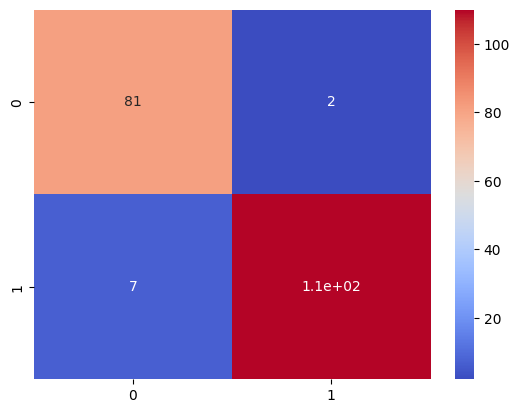

In [36]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,cmap='coolwarm')

In [37]:
cm

array([[ 81,   2],
       [  7, 110]])

In [39]:
# Ek results dataframe banao
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

# Original features ko wapas lao (X_test scaled nahi, original wala)
# Taaki tum values dekh sako (e.g., Age=65, Cholesterol=400)
error_indices = results_df[results_df['Actual'] != results_df['Predicted']].index
errors = X_test.loc[error_indices].copy()
errors['Actual'] = y_test.loc[error_indices]
errors['Predicted'] = results_df.loc[error_indices, 'Predicted'].values

# Ab is 'errors' dataframe ko analyze karo
errors.head(9)

,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,Actual,Predicted
513,34,1,0,158,0,0,0,172,0,1.4,1,0,1,0
235,78,0,2,104,0,0,1,137,1,1.9,2,2,1,0
947,51,0,2,133,218,0,2,171,1,0.8,1,2,1,0
139,25,1,0,158,336,0,1,85,1,2.0,1,2,0,1
439,61,1,0,140,0,0,2,121,1,0.2,1,0,1,0
764,50,0,2,200,279,0,2,122,0,1.0,1,0,1,0
534,59,1,2,104,371,0,0,193,1,1.2,1,2,1,0
445,29,1,0,158,0,0,2,120,0,1.4,1,0,1,0
208,36,1,2,135,342,0,1,187,0,0.9,1,2,0,1


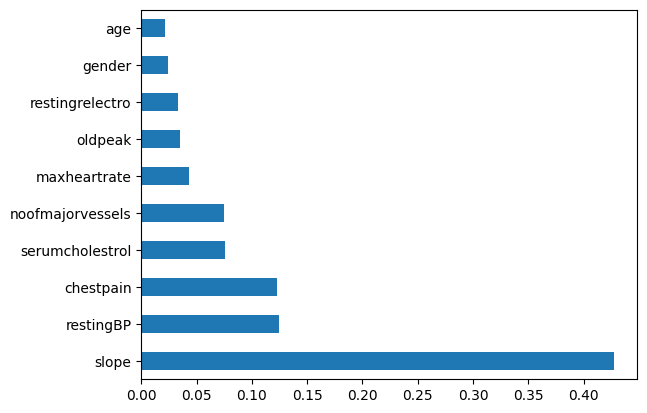

In [50]:
import matplotlib.pyplot as plt
best_model=rfc
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [53]:
y_probs = best_model.predict_proba(X_test_scaled)[:, 1]
custom_threshold = 0.45
y_pred_new = (y_probs >= custom_threshold).astype(int)
print("New Recall:", recall_score(y_test, y_pred_new))
print("New Confusion Matrix:\n", confusion_matrix(y_test, y_pred_new))

New Recall: 1.0
New Confusion Matrix:
 [[ 80   3]
 [  0 117]]


In [54]:
import pickle
with open('heart_model.pkl','wb') as model_file:
    pickle.dump(best_model, model_file)
    print("✅ Model saved successfully as heart_model.pkl")
with open('scaler.pkl','wb') as scaler_file:
    pickle.dump(scaler, scaler_file)
    print("✅ Scaler saved successfully as scaler.pkl")

✅ Model saved successfully as heart_model.pkl
✅ Scaler saved successfully as scaler.pkl
